In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

In [ ]:
df = pd.read_csv("Dataset.csv")
df.sample(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
710,711,22,Male,Scarf,Accessories,91,Virginia,L,Turquoise,Spring,4.1,Yes,Standard,Yes,Yes,26,PayPal,Fortnightly
1067,1068,18,Male,Dress,Clothing,43,Pennsylvania,S,Peach,Summer,2.7,No,2-Day Shipping,Yes,Yes,22,PayPal,Quarterly
1325,1326,28,Male,Backpack,Accessories,73,Oregon,L,Gold,Summer,3.5,No,Express,Yes,Yes,1,Cash,Monthly
3658,3659,28,Female,T-shirt,Clothing,72,Mississippi,M,Magenta,Fall,4.6,No,Standard,No,No,18,PayPal,Fortnightly
591,592,47,Male,Backpack,Accessories,37,Kentucky,L,Olive,Fall,4.2,Yes,Store Pickup,Yes,Yes,6,Debit Card,Bi-Weekly


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount_(usd),0
location,0
size,0
color,0
season,0


In [ ]:
median = df['review_rating'].median()
df['review_rating'] = df['review_rating'].fillna(median)
print(f"Filled 37 missing values with median in review_rating = {median}")

Filled 37 missing values with median in review_rating = 3.8


In [ ]:
for col in ['discount_applied', 'promo_code_used', 'subscription_status']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:
frequency_map = {'Weekly': 5, 'Bi-Weekly': 4, 'Fortnightly': 4, 'Monthly': 3, 'Every 3 Months': 2, 'Quarterly': 2, 'Annually': 1}
df['frequency_score'] = df['frequency_of_purchases'].map(frequency_map)

In [ ]:
dupli = df.duplicated(subset='customer_id').sum()
print(f"Duplicate customer IDs found: {dupli}")
print(f"Data cleaned. Shape: {df.shape}")

Duplicate customer IDs found: 0
Data cleaned. Shape: (3900, 19)


> FEATURE 1: PROMO DEPENDENCY SCORE: measures how much each customer relies on promotions (0: completely organic, 1: fully promo dependent)
* Answers the question of "Whether customers buy out of genuine brand affinity or only when incentivised by a discount?"

In [ ]:
df['promo_dependency_score'] = (df['discount_applied'] + df['promo_code_used']) / 2                     #average of the two binary signals

print(df['promo_dependency_score'].value_counts().sort_index())
print(f"{(df['promo_dependency_score']==1).sum()} customers are fully promo dependent")
print(f"That is {(df['promo_dependency_score']==1).mean()*100:.1f}% of the base")

promo_dependency_score
0.0    2223
1.0    1677
Name: count, dtype: int64
1677 customers are fully promo dependent
That is 43.0% of the base


>FEATURE 2: VALUE TIER: ranks every customer into 4 tiers by commercial value (Low -> Mid -> High -> Champion)
* Score: weighted average of normalized spend, frequency and prev purchases(due to the lack of chronological timestamps, purchase volume to be utilized as the proxy for time with brand)
* Answers "How commercially valuable is this customer to the brand right now and going forward?"

In [ ]:
def normalize(val):
    return (val - val.min()) / (val.max() - val.min())

df['spend_norm']   = normalize(df['purchase_amount_(usd)'])
df['freq_norm']    = normalize(df['frequency_score'])
df['prev_norm']    = normalize(df['previous_purchases'])

df['value_score'] = (0.4 * df['spend_norm'] + 0.3 * df['freq_norm']  + 0.3 * df['prev_norm'])

df['value_tier'] = pd.qcut(df['value_score'],q=4,labels=['Low', 'Mid', 'High', 'Champions'])

print("Value Tier distribution:")
print(df['value_tier'].value_counts().sort_index())
print("\nAvg spend per tier:")
print(df.groupby('value_tier', observed=True)['purchase_amount_(usd)'].mean().round(2))

Value Tier distribution:
value_tier
Low          976
Mid          974
High         975
Champions    975
Name: count, dtype: int64

Avg spend per tier:
value_tier
Low          39.18
Mid          54.07
High         65.40
Champions    80.43
Name: purchase_amount_(usd), dtype: float64


>FEATURE 3: SATISFACTION FLAG: 1 = satisfied, 0 = not satisfied; based on review_rating with threshold of 3.5 out of 5.0
* Answers "Is this customer happy enough to return without a promotional push?"

In [ ]:
threshold = 3.5
df['satisfaction_flag'] = (df['review_rating'] >= threshold).astype(int)        # astype(int) converts True -> 1, False -> 0

print(f"Satisfied customers: {df['satisfaction_flag'].mean()*100:.1f}%")
print(f"(threshold = {threshold}): {df['satisfaction_flag'].value_counts().sort_index()}")

Satisfied customers: 62.1%
(threshold = 3.5): satisfaction_flag
0    1478
1    2422
Name: count, dtype: int64


LOYALTY DEFINITION (A):
"A customer is loyal if they buy frequently and have bought many times before"

*   First we normalise frequency_score and previous_purchases [FORMULA:       (value-minimum)/(maximum-minimum)]
*   We multiply frequency_score and previous_purchases (normalised)
*   Top 40% of this score = classified as Loyal under Definition A

In [ ]:
freq_min, freq_max = df['frequency_score'].min(), df['frequency_score'].max()
prev_min, prev_max = df['previous_purchases'].min(), df['previous_purchases'].max()
freq_norm = (df['frequency_score']-freq_min)/(freq_max-freq_min)
prev_norm = (df['previous_purchases']-prev_min)/(prev_max-prev_min)

df['defA_score'] = (freq_norm)*(prev_norm)

threshA = df['defA_score'].quantile(0.60)                                        #The top 40% (above 60th percentile) as Loyal (1)
df['loyal_A'] = (df['defA_score'] >= threshA).astype(int)                        #converts to binary (0/1)

discountcheck = df.groupby('loyal_A')['promo_dependency_score'].mean().round(3)       #This checks if our loyal customers rely heavily on discount or not
print(discountcheck)

loyal_A
0    0.418
1    0.447
Name: discount_applied, dtype: float64


Def A loyals have higher discount dependency than the non loyals, meaning Def A fails by labeling discount buyers as loyal.

LOYALTY DEFINITION (B):
"A customer is loyal if they spend more and do not need discounts/promos for their purchases"
*   FORMULA: (spend_norm)*(1 - promo_dependency_score)
*   If promo_dependency_score= 1, then score becomes 0, no matter how much they spent
*   If promo_dependency_score= 0, then score = spend_norm
*   This directly answers "Is the brand building loyalty or discount dependency?"

In [ ]:
spend_min, spend_max = df['purchase_amount_(usd)'].min(), df['purchase_amount_(usd)'].max()
spend_norm = (df['purchase_amount_(usd)']-spend_min)/(spend_max-spend_min)

df['defB_score'] = (spend_norm)*(1 - df['promo_dependency_score'])

threshB = df['defB_score'].quantile(0.60)
df['loyal_B'] = (df['defB_score'] >= threshB).astype(int)

print(f"DefB loyal: {df['loyal_B'].sum()} ({df['loyal_B'].mean()*100:.1f}%)")
print(df.groupby('loyal_B')['promo_dependency_score'].mean().round(3))                #checks discount dependency in loyal B customers (zero percent)


DefB loyal: 1575 (40.4%)
loyal_B
0    0.721
1    0.000
Name: discount_applied, dtype: float64


Choosing between defA and defB: The one with higher correlation with purchase_amount_(usd) wins


In [ ]:
corr_A = df['loyal_A'].corr(df['purchase_amount_(usd)'])                        #calculates correlation of defA loyal with purchase_amount_(usd)
corr_B = df['loyal_B'].corr(df['purchase_amount_(usd)'])

discount_A = df[df['loyal_A'] == 1]['promo_dependency_score'].mean()                  #calculates the discount average dependencies among loyals for both groups
discount_B = df[df['loyal_B'] == 1]['promo_dependency_score'].mean()

print("Def A (Frequency*Tenure):")
print(f" Correlation with revenue (r): {corr_A:.4f}")
print(f" Promo dependency among loyal : {discount_A:.3f}")

print("\nDef B (Spend*NoPromo):")
print(f" Correlation with revenue (r): {corr_B:.4f}")
print(f" Promo dependency among loyal : {discount_B:.3f}")

Def A (Frequency*Tenure):
 Correlation with revenue (r): 0.0050
 Discount use among loyal : 0.447

Def B (Spend*NoPromo):
 Correlation with revenue (r): 0.4291
 Discount use among loyal : 0.000


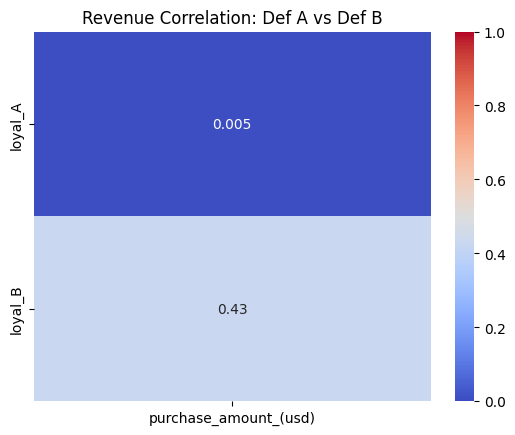

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
hmap = df[['loyal_A', 'loyal_B', 'purchase_amount_(usd)']].corr()

sns.heatmap(df[['loyal_A', 'loyal_B', 'purchase_amount_(usd)']].corr()[['purchase_amount_(usd)']].drop('purchase_amount_(usd)', axis =0), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Revenue Correlation: Def A vs Def B")
plt.show()

Final verdict: DefB is preferred.
Reasons:
>(1) **Correlation with revenue**:
* Def A correlation with revenue is practically zero (r=0.005), meaning its "loyal" tag cannot predict if a customer actually drives financial growth.
* Def B achieves a strong, positive correlation (r = 0.430), proving that it focuses on high-value customers who directly affect the company's revenue.

>(2) **Discount chasers disguised as loyal**:
* Def A labels customers with 44.7% avg discount dependency as 'loyal' who actually are simply chasing promotions, not loyality.
* Def B labels customers with 0.0% discount dependency as 'loyal' who are genuinely organic, high value buyers.

>(3) **Answers key question**:
* It's asked in the problem statement 'Is the brand building loyalty or discount dependency?'
* Def A cannot separate the two. Def B tells them apart.

>**RISK & MITIGATION OF CHOOSING DEFINITION B**:
* Risk: We may miss frequent, low spend loyal buyers.
* Mitigation: Cross-check Def B results against 'previous_purchases'
to ensure long term low spenders are captured in final segments.

In [ ]:
cutoff = df['previous_purchases'].median()

missed_loyalB = df[(df['loyal_B'] == 0) & (df['previous_purchases'] > cutoff)]

print("Number of missed frequent buyers:", len(missed_loyalB))                  #shows the number of frequent, low spending loyal buyers who were missed due to defB's focus on heavy spend.
print(missed_loyalB[['previous_purchases', 'purchase_amount_(usd)']].head())

Number of missed frequent buyers: 1142
    previous_purchases  purchase_amount_(usd)
3                   49                     90
4                   31                     49
6                   49                     85
10                  26                     34
12                  37                     72


Now, we will describe the ***metrics*** to be used.
>Metric 1: **Organic Revenue Rate (ORR)**: The percentage of total revenue that comes from customers who bought without using any discount or promo code.
>It answers: "Can this brand survive without discounts?"

>ORR ≥ 55% : Brand has organic foundation, safe to begin reducing promos.

>ORR < 55% : Brand is discount dependent, removing promos will hurt volume.


In [ ]:
total_revenue = df['purchase_amount_(usd)'].sum()
organic_revenue = df[df['discount_applied'] == 0]['purchase_amount_(usd)'].sum()
promo_revenue = df[df['discount_applied'] == 1]['purchase_amount_(usd)'].sum()

orr = (organic_revenue / total_revenue) * 100                                   #ORR percentage

print(f"Total Revenue   : ${total_revenue:,.2f}")
print(f"Organic Revenue : ${organic_revenue:,.2f} ({orr:.1f}%)")
print(f"Promo Revenue   : ${promo_revenue:,.2f} ({100-orr:.1f}%)")
print(f"Final ORR Score : {orr:.1f}% (Target Benchmark: 55.0%)")

if orr >= 55:
    print("Brand has a safe organic foundation.")
else:
    print("Brand is heavily discount dependent.")

Total Revenue   : $233,081.00
Organic Revenue : $133,670.00 (57.3%)
Promo Revenue   : $99,411.00 (42.7%)
Final ORR Score : 57.3% (Target Benchmark: 55.0%)
Brand has a safe organic foundation.


>Metric 2: **Loyalty Conversion Efficiency (LCE)**: Among customers who have been with the brand the longest, (top 25% by previous_purchases), what % are genuinely loyal?

>If time with brand built loyalty, then oldest customers must also be loyal. If not, then the brand is just making customers to expect discounts in future course of time.

>LCE ≥ 40% : Converting to loyalty, retention works.

>LCE < 40% : Not converting, habitual to discounts.

In [ ]:
thresh = df['previous_purchases'].quantile(0.75)
old_custs = df[df['previous_purchases'] >= thresh]

loyal_old = old_custs[old_custs['loyal_B'] == 1]
lce = (len(loyal_old) / len(old_custs)) * 100

# 2. Print LCE Summary Report
print(f"Threshold (Top 25%)     : {thresh:.0f} past purchases")
print(f"Old customers           : {len(old_custs)}")
print(f"Genuinely Loyal (Def B) : {len(loyal_old)}")
print(f"Final LCE Score         : {lce:.1f}% (Target Benchmark: 40.0%)", end = "\n\n")

if lce >= 40:
    print("Tenure is converting to loyalty.")
else:
    print("Tenure is NOT converting to loyalty.")
    print("The brand has been training its oldest customers to expect discounts.")

Threshold (Top 25%)     : 38 past purchases
Old customers           : 998
Genuinely Loyal (Def B) : 391
Final LCE Score         : 39.2% (Target Benchmark: 40.0%)

Tenure is NOT converting to loyalty.
The brand has been training its oldest customers to expect discounts.


>Metric 3: **Segment Migration Potential (SMP)**: For each promo hunting customer, what would they actually spend if they were converted to organic buyers?

>Calculated by matching them to organic buyers in the same gender, category and taking the average spend difference.

>Positive SMP = converting this group grows revenue.

>Negative SMP = converting this group shrinks revenue.

In [ ]:
avg_spend = df.groupby(['gender', 'category', 'discount_applied'])['purchase_amount_(usd)'].mean()
counts = df.groupby(['gender', 'category', 'discount_applied'])['customer_id'].count()

smp_rows = []

for gender in df['gender'].unique():                                            #loop through each combination of gender and category
    for category in df['category'].unique():

        n_organic = counts.get((gender, category, 0), 0)
        n_promo = counts.get((gender, category, 1), 0)

        if n_organic >= 1:
            organic_avg = avg_spend[(gender, category, 0)]

            promo_avg = avg_spend.get((gender, category, 1), 0.0)

            net = organic_avg - promo_avg
            total_impact = net*(n_promo)

            smp_rows.append({'gender': gender, 'category': category, 'n_promo_customers': n_promo, 'promo_avg_spend': round(promo_avg, 2), 'organic_avg_spend': round(organic_avg, 2), 'smp_per_customer': round(net, 2), 'total_revenue_impact': total_impact})

smp_df = pd.DataFrame(smp_rows).sort_values('total_revenue_impact', ascending=False)
print(smp_df.to_string(index=False))
total_smp = smp_df['total_revenue_impact'].sum()
print(f"\nTOTAL SMP (if all promo hunters converted): ${total_smp:,.0f}")

discount_stats = df.groupby('gender')['discount_applied'].mean()*100
loyalty_stats = df.groupby('gender')['loyal_B'].mean()*100
print((discount_stats).round(2))
print((loyalty_stats).round(2))

gender_percentages = df['gender'].value_counts(normalize=True)*100
print(gender_percentages.astype(str)+"%")

gender    category  n_promo_customers  promo_avg_spend  organic_avg_spend  smp_per_customer  total_revenue_impact
  Male Accessories                543            58.49              61.05              2.56           1391.485246
  Male   Outerwear                144            55.32              58.95              3.63            522.708861
  Male    Clothing                731            59.75              59.89              0.13             98.153333
Female    Clothing                  0             0.00              60.50             60.50              0.000000
Female   Outerwear                  0             0.00              58.43             58.43              0.000000
Female    Footwear                  0             0.00              59.47             59.47              0.000000
Female Accessories                  0             0.00              60.76             60.76              0.000000
  Male    Footwear                259            61.80              58.52             -3

KEY FINDING:
>Female customers --> 0% discount dependency, 71% loyalty

>Male customers --> 63% discount dependency, 25% loyalty

>Proportion of men: 68% (majority)

>This clearly shows that the company acquired a male majority customer base and ran promos to retain them.

In [ ]:
gender_summary = df.groupby('gender')[['purchase_amount_(usd)', 'discount_applied', 'loyal_B', 'previous_purchases', 'review_rating']].mean()               #group by gender and get the averages for all numeric metrics

gender_summary.columns = ['avg_spend', 'avg_promo', 'percent_loyal_B', 'avg_prev', 'avg_rating']

gender_summary['n'] = df['gender'].value_counts()

gender_summary['percent_of_base'] = (gender_summary['n'] / len(df) * 100).round(1)

gender_summary = gender_summary.round(3)

print(gender_summary.to_string())

print("\nACQUISITION MIX SIMULATION")

female_n = gender_summary.loc['Female', 'n']
male_n = gender_summary.loc['Male', 'n']
total_n = female_n + male_n

female_loyal_rate = gender_summary.loc['Female', 'percent_loyal_B']
male_loyal_rate = gender_summary.loc['Male', 'percent_loyal_B']

current_loyal = (female_n * female_loyal_rate) + (male_n * male_loyal_rate)

simulated_n = total_n / 2                                                           #50/50 split
simulated_loyal = (simulated_n * female_loyal_rate) + (simulated_n * male_loyal_rate)
loyal_net = simulated_loyal - current_loyal

avg_spend_loyal = df[df['loyal_B'] == 1]['purchase_amount_(usd)'].mean()            #revenue lift
avg_spend_total = df['purchase_amount_(usd)'].mean()
revenue_net = loyal_net * (avg_spend_loyal - avg_spend_total)

print(f"Current: {female_n:.0f} female ({female_n / total_n * 100:.1f}%)")
print(f"         {male_n:.0f} male ({male_n / total_n * 100:.1f}%)")
print(f"Current loyal customer base: {current_loyal:.0f} ({current_loyal / total_n * 100:.1f}%)")

print(f"\nSimulated 50/50 split: {simulated_n:.0f} each")
print(f"Simulated loyal base: {simulated_loyal:.0f} ({simulated_loyal / total_n * 100:.1f}%)")
print(f"Lift from fixing acquisition mix: +{loyal_net:.0f} loyal customers")
print(f"Revenue lift: +${revenue_net:.0f}")

        avg_spend  avg_promo  percent_loyal_B  avg_prev  avg_rating     n  percent_of_base
gender                                                                                    
Female     60.249      0.000            0.719    24.596       3.741  1248             32.0
Male       59.536      0.632            0.256    25.707       3.755  2652             68.0

ACQUISITION MIX SIMULATION
Current: 1248 female (32.0%)
         2652 male (68.0%)
Current loyal customer base: 1576 (40.4%)

Simulated 50/50 split: 1950 each
Simulated loyal base: 1901 (48.8%)
Lift from fixing acquisition mix: +325 loyal customers
Revenue lift: +$4013


ROOT CAUSE:
> The brand's discount problem is not behavioral. 67% of the customer base is male. Male customers show 63% discount dependency and 25% loyalty across all age bands.

> Female customers show 0% discount dependency and 70%+ loyalty across all age bands.

> This uniformity across age bands rules out age as a responsible factor.

> Marketing team is, by accident, targeting mostly men. On top of that, because it keeps sending generic discounts to everyone, the brand has trained these male customers to only buy things when they have a coupon. The data tracking over time proves this is exactly what happened.

> So, fixing the discount problem by removing promos alone will lose revenue.

> Shifting acquisition toward female demographics structurally improves the customer base quality.

SEGMENT ASSIGNMENT:
>ORGANIC LOYALS:
* loyal_B = 1
* Meaning: high spend + zero discount dependency
* These are the brand's real asset

>PROMO DEPENDENT:
* loyal_B = 0 and discount_applied = 1
* Meaning: only buy when discounted
* These are the brand's real problem

>DISENGAGED:
* loyal_B = 0 and discount_applied = 0
* Meaning: low spend, not using discounts, not loyal
* These are quietly drifting away

In [ ]:
def assign_segment(row):
    if row['loyal_B'] == 1:
        return 'Organic Loyals'
    elif row['loyal_B'] == 0 and row['discount_applied'] == 1:
        return 'Promo Dependent'
    else:
        return 'Disengaged'

df['segment'] = df.apply(assign_segment, axis=1)

print("Segment counts:")
print(df["segment"].value_counts())

seg_profile = df.groupby("segment")[["purchase_amount_(usd)", "previous_purchases", "review_rating", "discount_applied", "subscription_status"]].mean()

seg_profile.columns = ["avg_spend", "avg_tenure", "avg_rating", "avg_promo_dep", "percent_subscribed"]

seg_profile["n"] = df["segment"].value_counts()
seg_profile["percent_of_base"] = (seg_profile["n"] / len(df) * 100).round(1)

df["is_female"] = (df["gender"] == "Female").astype(int)                                               #Female=1, Male=0
seg_profile["percent_female"] = (df.groupby("segment")["is_female"].mean() * 100).round(1)

seg_profile["percent_subscribed"] = (seg_profile["percent_subscribed"] * 100).round(1)

print("\nSegment profiles:")
print(seg_profile.round(2).to_string())

organic_sub = seg_profile.loc["Organic Loyals", "percent_subscribed"]
promo_sub = seg_profile.loc["Promo Dependent", "percent_subscribed"]

Segment counts:
segment
Promo Dependent    1677
Organic Loyals     1575
Disengaged          648
Name: count, dtype: int64

Segment profiles:
                 avg_spend  avg_tenure  avg_rating  avg_promo_dep  percent_subscribed     n  percent_of_base  percent_female
segment                                                                                                                     
Disengaged           31.01       24.78        3.75            0.0                 0.0   648             16.6            54.2
Organic Loyals       72.11       25.17        3.76            0.0                 0.0  1575             40.4            57.0
Promo Dependent      59.28       25.74        3.74            1.0                62.8  1677             43.0             0.0


SUBSCRIPTION PARADOX:
* Organic Loyals percent subscribed = 0.0%
* Promo Dependent percent subscribed = 62.8%

>The subscription program is used almost exclusively by promo hunting customers and almost never by organic ones.

>This means the subscription offering is perceived as a discount vehicle, not a brand membership mechanism.

>A subscription that your best customers never use is not a
loyalty program.


In [ ]:
print(f" ORR = {orr:.1f}% (threshold: 55%)")                                    #core metrics displayed
print(f" LCE = {lce:.1f}% (threshold: 40%)")

scenario_A = orr >= 55                                                          #scenarios explicitly mentioned
scenario_B = lce < 40

if scenario_A and not scenario_B:                                               #strategic paths
    scenario = "A : Brand is building genuine loyalty"
elif not scenario_A and scenario_B:
    scenario = "B : Brand is structurally discount dependent"
elif scenario_A and scenario_B:
    scenario = "Brand is mixed of both, at a tipping point"
else:
    scenario = "Unusual metric combo"

print(f"\nVERDICT: {scenario}")

 ORR = 57.3% (threshold: 55%)
 LCE = 39.2% (threshold: 40%)

VERDICT: Brand is mixed of both, at a tipping point


The brand is not in crisis, but it is not safe either.
Its oldest customers are becoming more promo dependent over time.
If this trend continues for 2-3 more years, ORR will fall below 55%
and the brand will be trapped in Scenario B permanently.

SCENARIO A: ***ACTION PLAN*** (since ORR just barely qualifies):
* Stop discounting Organic Loyals immediately
* Shift acquisition budget toward female demographics
* Redesign subscription as access product not discount vehicle

SCENARIO B: ***CONTINGENCY*** (if ORR drops below 55%):
* Do not remove promos (vol loss will occur)
* Introduce loyalty points currency to replace discount habit gradually
* Fix acquisition mix first

In [ ]:
cols_to_drop = ["is_female"]
final_df = df.drop(columns=cols_to_drop, errors="ignore")

final_df.to_csv("python_cleaning and feature engineering.csv", index=False)